# Furuno

In [1]:
import xarray as xr
from open_radar_data import DATASETS

import xradar as xd

## Download

Fetching Furuno radar data file from [open-radar-data](https://github.com/openradar/open-radar-data) repository.

In [2]:
filename_scnx = DATASETS.fetch("2006_20220324_000000_000.scnx.gz")
filename_scn = DATASETS.fetch("0080_20210730_160000_01_02.scn.gz")

## xr.open_dataset

Making use of the xarray `furuno` backend. 

### scn format

In [3]:
ds = xr.open_dataset(filename_scn, engine="furuno")
display(ds)

C:\Users\egoud\.venvs\wradlib\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'radolan' loading failed:
module 'wradlib.georef.raster' has no attribute 'read_gdal_values'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.Dataset> Size: 55MB
Dimensions:            (azimuth: 1376, range: 602)
Coordinates:
  * azimuth            (azimuth) float64 11kB 0.21 0.47 0.74 ... 359.7 359.9
    elevation          (azimuth) float64 11kB ...
  * range              (range) float32 2kB 25.0 75.0 ... 3.002e+04 3.008e+04
    time               (azimuth) datetime64[ns] 11kB ...
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           float64 8B ...
Data variables: (12/14)
    RATE               (azimuth, range) float64 7MB ...
    DBZH               (azimuth, range) float64 7MB ...
    VRADH              (azimuth, range) float64 7MB ...
    ZDR                (azimuth, range) float64 7MB ...
    KDP                (azimuth, range) float64 7MB ...
    PHIDP              (azimuth, range) float64 7MB ...
    ...                 ...
    QUAL               (azimuth, range) uint16 2MB ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
Attributes:
    source:            Furuno
    version:           3
    radar_constant_h:  9.575470000000001e-17
    radar_constant_v:  9.144499999999999e-17

#### Plot Time vs. Azimuth

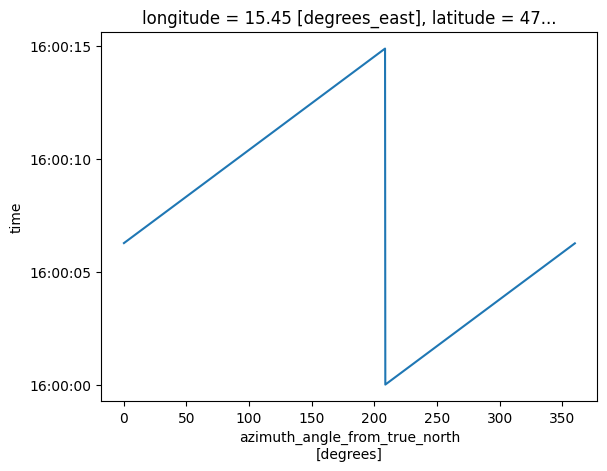

In [4]:
ds.azimuth.plot(y="time")

#### Plot Range vs. Time

We need to sort by `time` and specify the y-coordinate.

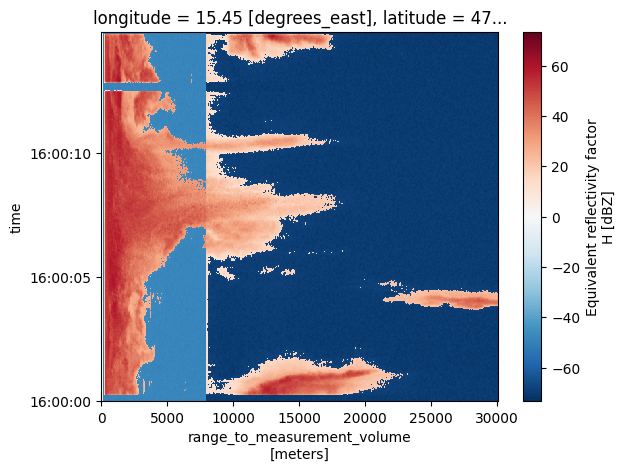

In [5]:
ds.DBZH.sortby("time").plot(y="time")

#### Plot Range vs. Azimuth

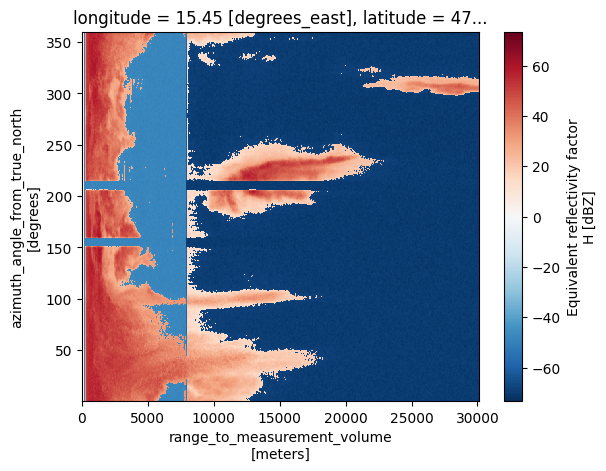

In [6]:
ds.DBZH.sortby("azimuth").plot(y="azimuth")

### scnx format

In [7]:
ds = xr.open_dataset(filename_scnx, engine="furuno")
display(ds)

<xarray.Dataset> Size: 45MB
Dimensions:            (azimuth: 722, range: 936)
Coordinates:
  * azimuth            (azimuth) float64 6kB 0.19 0.68 1.16 ... 359.2 359.7
    elevation          (azimuth) float64 6kB ...
  * range              (range) float32 4kB 37.5 112.5 ... 7.009e+04 7.016e+04
    time               (azimuth) datetime64[ns] 6kB ...
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           float64 8B ...
Data variables: (12/14)
    RATE               (azimuth, range) float64 5MB ...
    DBZH               (azimuth, range) float64 5MB ...
    VRADH              (azimuth, range) float64 5MB ...
    ZDR                (azimuth, range) float64 5MB ...
    KDP                (azimuth, range) float64 5MB ...
    PHIDP              (azimuth, range) float64 5MB ...
    ...                 ...
    QUAL               (azimuth, range) uint16 1MB ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
Attributes:
    source:                     Furuno
    version:                    10
    antenna_gain_h:             337
    antenna_gain_v:             338
    tx_power_h:                 724
    tx_power_v:                 708
    radar_constant_h:           -1294
    radar_constant_v:           -1296
    noise_power_short_pulse_h:  -604

#### Plot Time vs. Azimuth

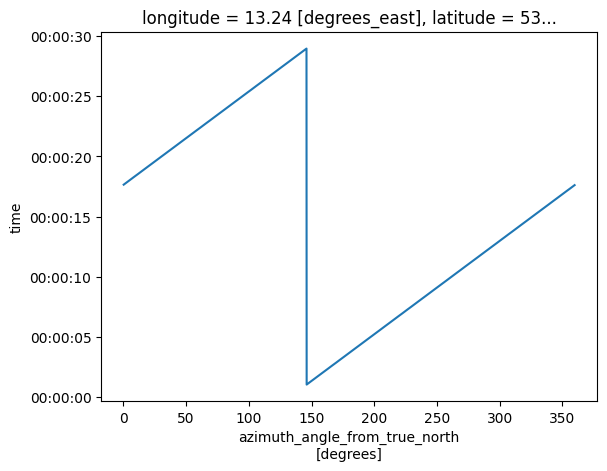

In [8]:
ds.azimuth.plot(y="time")

#### Plot Range vs. Time

We need to sort by `time` and specify the y-coordinate.

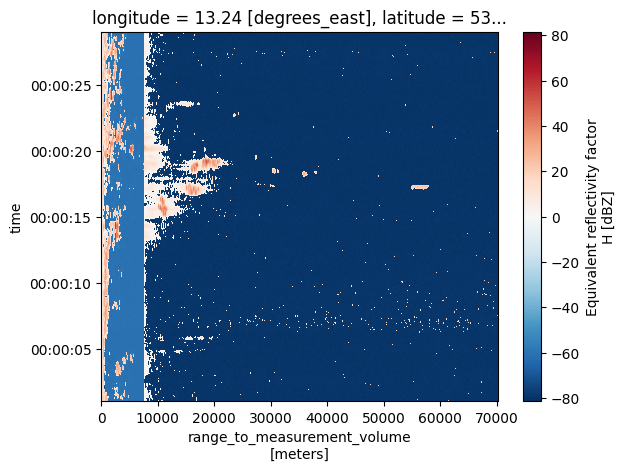

In [9]:
ds.DBZH.sortby("time").plot(y="time")

#### Plot Range vs. Azimuth

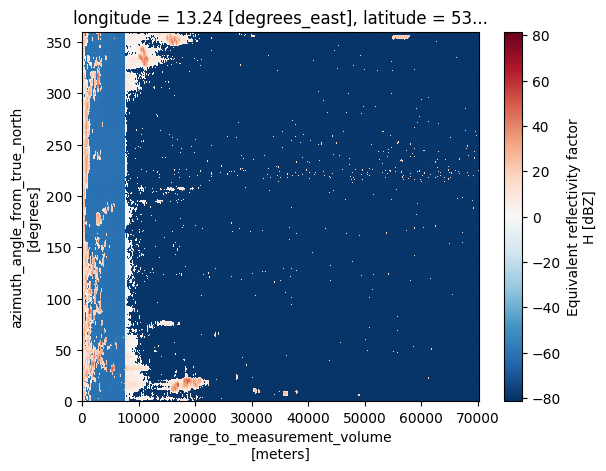

In [10]:
ds.DBZH.sortby("azimuth").plot(y="azimuth")

## open_furuno_datatree

Furuno scn/scnx files consist only of one sweep. But we might load and combine several sweeps into one DataTree.

In [11]:
dtree = xd.io.open_furuno_datatree(filename_scn)
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2021-07-30T16:00:00Z'
│       time_coverage_end    <U20 80B '2021-07-30T16:00:14Z'
│       longitude            float64 8B 15.45
│       altitude             float64 8B 407.9
│       latitude             float64 8B 47.08
│       sweep_fixed_angle    (sweep) float64 8B 7.8
│       sweep_group_name     (sweep) int64 8B 0
│   Attributes:
│       Conventions:      None
│       instrument_name:  None
│       version:          3
│       title:            None
│       institution:      None
│       references:       None
│       source:           Furuno
│       history:          None
│       comment:          im/exported using xradar
├── Group: /sweep_0
│       Dimensions:            (azimuth: 1376, range: 602)
│       Coordinates:
│         * azimuth            (azimuth) float64 11kB 0.21 0.47 0.74 ... 359.7 359.9
│           elevation          (azimuth) float64 11kB ...
│         * range              (range) float32 2kB 25.0 75.0 ... 3.002e+04 3.008e+04
│           time               (azimuth) datetime64[ns] 11kB 2021-07-30T16:00:06.2777...
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables: (12/14)
│           RATE               (azimuth, range) float64 7MB ...
│           DBZH               (azimuth, range) float64 7MB ...
│           VRADH              (azimuth, range) float64 7MB ...
│           ZDR                (azimuth, range) float64 7MB ...
│           KDP                (azimuth, range) float64 7MB ...
│           PHIDP              (azimuth, range) float64 7MB ...
│           ...                 ...
│           QUAL               (azimuth, range) uint16 2MB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /radar_parameters
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
├── Group: /georeferencing_correction
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
└── Group: /radar_calibration
        Dimensions:           ()
        Data variables:
            radar_constant_h  float64 8B 9.575e-17
            radar_constant_v  float64 8B 9.144e-17

### Plot Sweep Range vs. Time

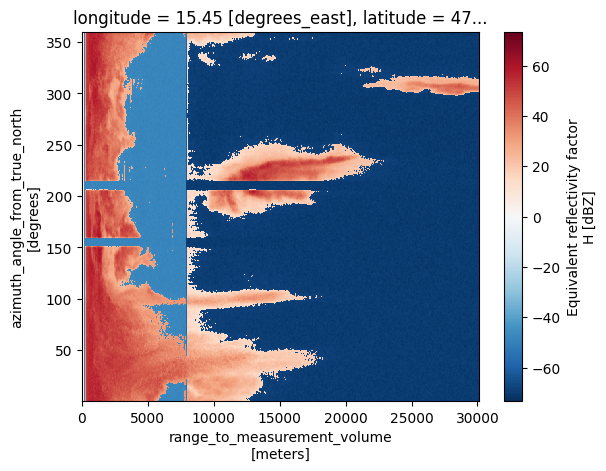

In [12]:
dtree["sweep_0"].ds.DBZH.plot()

### Plot Sweep Range vs. Azimuth

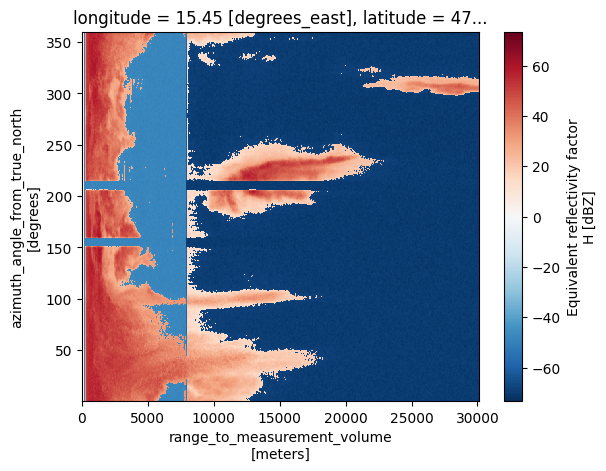

In [13]:
dtree["sweep_0"].ds.DBZH.sortby("azimuth").plot(y="azimuth")